In [1]:
"""
This script is used to run topic modelling

authors: Roy Oelen, Martijn van der Werf

"""

'\nThis script is used to run topic modelling\n\nauthors: Roy Oelen, Martijn van der Werf\n\n'

In [2]:
# imports
from pycisTopic.cistopic_class import CistopicObject
from scipy.sparse import csr_matrix
from scipy.io import mmread
import gzip
from sklearn.preprocessing import binarize
import pandas as pd
import os
from pycisTopic.lda_models import run_cgs_models_mallet
from numpy.random import choice
from pycisTopic.lda_models import evaluate_models
import pickle
import numpy as np
import glob
import re


/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-02-19 13:32:37,732	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [3]:
##############################
# read the pycistopic object #
##############################

# location to store the object
pycistopic_object_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/objects/merged_major_and_minor_celltypes.pkl'
# use symlinks due to path size limitations
pycistopic_object_loc = './s'

# save the object
with open(pycistopic_object_loc, 'rb') as f:
   cistopic_obj = pickle.load(f)


In [4]:
########################################
# prepare LDA on the pycistopic object #
########################################

# LDA will use Mallet, set the memory to be large enough
os.environ['MALLET_MEMORY'] = '720G'

# path to the Mallet binary
mallet_path = '/groups/umcg-franke-scrna/tmp04/software/Mallet-202108/bin/mallet'
# use symlinks due to path size limitations
mallet_path = './m'

# set temp directory
tmp_directory = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/tmp_space/'
# use symlinks due to path size limitations
tmp_directory = './t/'

# set where we save the pickles
models_save_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/models/all_nuclei_and_regions_major_minor/'
# use symlinks due to path size limitations
models_save_loc = './o/'


In [ ]:
####################################
# run LDA on the pycistopic object #
####################################

# get the models
models = run_cgs_models_mallet(
    cistopic_obj,
    n_topics = [40, 80, 120],
    n_cpu = 16,
    n_iter = 500,
    random_state = 7777,
    alpha = 50,
    alpha_by_topic = True,
    eta = 0.1,
    eta_by_topic = False,
    tmp_path = tmp_directory,
    save_path = models_save_loc,
    mallet_path = mallet_path,
)


In [7]:
##############################################
# reload models if environment has restarted #
##############################################


# list the pkls of each model
model_file_list = glob.glob(os.path.join(models_save_loc, "Topic*.pkl"))

# put them in a list
models = []

# by reading each one of them
for file_path in model_file_list:
    with open(file_path, "rb") as f_input:
        models.append(pickle.load(f_input))


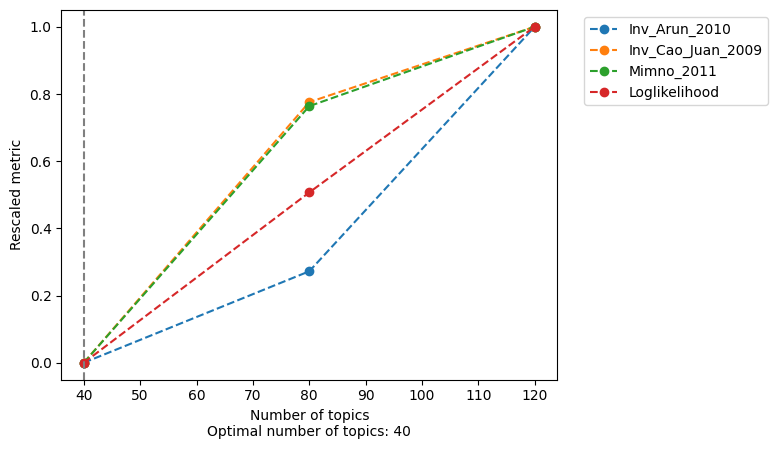

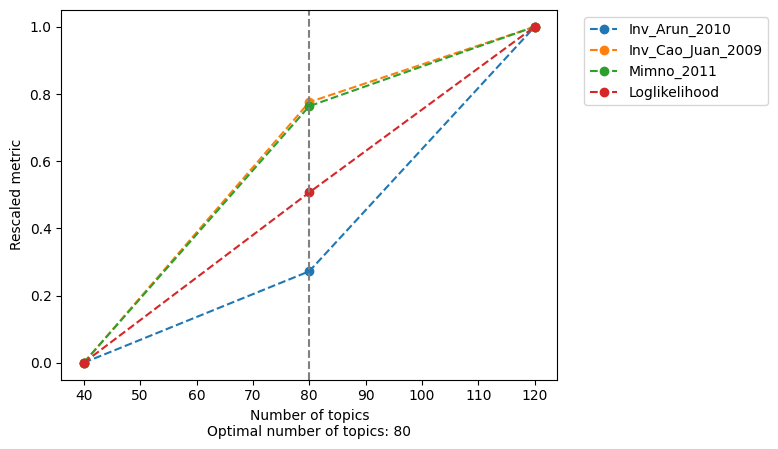

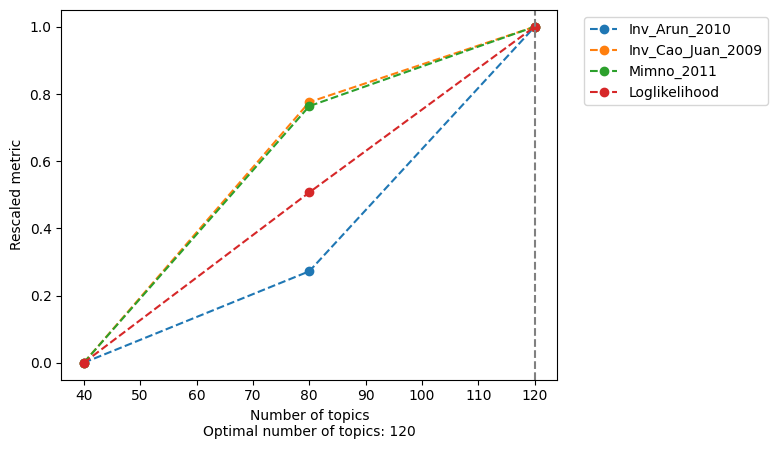

In [8]:
#######################
# evaluate the models #
#######################

# location to save the plots
model_plots_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/models/all_nuclei_and_regions_major_minor/model_plots/'
# use symlinks due to path size limitations
model_plots_loc = './p/'

# select and plot model 40
model = evaluate_models(
    models,
    return_model = True,
    select_model = 40,
    save=os.path.join(model_plots_loc, 'model_evaluation_40_topics.pdf')
)
# select and plot model 80
model = evaluate_models(
    models,
    return_model = True,
    select_model = 80,
    save=os.path.join(model_plots_loc, 'model_evaluation_80_topics.pdf')
)
# select and plot model 120
model = evaluate_models(
    models,
    return_model = True,
    select_model = 120,
    save=os.path.join(model_plots_loc, 'model_evaluation_120_topics.pdf'), 
    
)

In [9]:
evaluate_models

<function pycisTopic.lda_models.evaluate_models(models: 'list[CistopicLDAModel]', select_model: 'int | None' = None, return_model: 'bool' = True, metrics: 'str' = ['Minmo_2011', 'loglikelihood', 'Cao_Juan_2009', 'Arun_2010'], min_topics_coh: 'int' = 5, plot: 'bool' = True, figsize: 'tuple[float, float]' = (6.4, 4.8), plot_metrics: 'bool' = False, save: 'str | None' = None)>